In [1]:
pip install tensorflow==2.18.0


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow==2.18.0 (from versions: none)
ERROR: No matching distribution found for tensorflow==2.18.0


In [2]:
pip install keras==3.7.0

     ---------------------------------------- 1.2/1.2 MB 248.3 kB/s eta 0:00:00
     ------------------------------------- 290.9/290.9 kB 64.8 kB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.4.0
    Uninstalling typing_extensions-4.4.0:
      Successfully uninstalled typing_extensions-4.4.0
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.7.0 which is incompatible.


In [3]:
pip install optree

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install keras==3.7.0

Note: you may need to restart the kernel to use updated packages.


In [5]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 # For Sequential models
from keras.models import Model        # For functional API models (if needed)
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [6]:
IMAGE_SIZE = [224, 224]

In [7]:
train_directory='C:/Users/hp/OneDrive/Desktop/lung cancer detection using streamlit/Lung-Cancer-Detection-main/Data_n_experiments/train/'
test_directory='C:/Users/hp/OneDrive/Desktop/lung cancer detection using streamlit/Lung-Cancer-Detection-main/Data_n_experiments/test/'
val_directory='C:/Users/hp/OneDrive/Desktop/lung cancer detection using streamlit/Lung-Cancer-Detection-main/Data_n_experiments/valid/'

In [ ]:


 
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# don't train existing weights
for layer in vgg.layers:
  layer.trainable = False

47063040/58889256 ━━━━━━━━━━━━━━━━━━━━ 4:52 25us/step

In [ ]:
  # useful for getting number of classes
folders = glob('C:/Users/hp/OneDrive/Desktop/lung cancer detection using streamlit/Lung-Cancer-Detection-main/Data_n_experiments/valid/*')
len(folders)

2

In [52]:
# our layers - you can add more if you want
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [53]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [54]:
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

In [55]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory(train_directory,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_set = test_datagen.flow_from_directory(test_directory,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 1371 images belonging to 2 classes.
Found 1371 images belonging to 2 classes.


In [56]:
print(len(training_set))
print(len(test_set))

43
43


In [57]:
import scipy
from scipy import linalg
print(linalg.__doc__)



Linear algebra (:mod:`scipy.linalg`)

.. currentmodule:: scipy.linalg

.. toctree::
   :hidden:

   linalg.blas
   linalg.cython_blas
   linalg.cython_lapack
   linalg.interpolative
   linalg.lapack

Linear algebra functions.

.. eventually, we should replace the numpy.linalg HTML link with just `numpy.linalg`

.. seealso::

   `numpy.linalg <https://www.numpy.org/devdocs/reference/routines.linalg.html>`__
   for more linear algebra functions. Note that
   although `scipy.linalg` imports most of them, identically named
   functions from `scipy.linalg` may offer more or slightly differing
   functionality.


Basics

.. autosummary::
   :toctree: generated/

   inv - Find the inverse of a square matrix
   solve - Solve a linear system of equations
   solve_banded - Solve a banded linear system
   solveh_banded - Solve a Hermitian or symmetric banded system
   solve_circulant - Solve a circulant system
   solve_triangular - Solve a triangular matrix
   solve_toeplitz - Solve a toeplitz m

In [58]:
from scipy import ndimage
from scipy import linalg
print(ndimage.__doc__)



Multidimensional image processing (:mod:`scipy.ndimage`)

.. currentmodule:: scipy.ndimage

This package contains various functions for multidimensional image
processing.


Filters

.. autosummary::
   :toctree: generated/

   convolve - Multidimensional convolution
   convolve1d - 1-D convolution along the given axis
   correlate - Multidimensional correlation
   correlate1d - 1-D correlation along the given axis
   gaussian_filter
   gaussian_filter1d
   gaussian_gradient_magnitude
   gaussian_laplace
   generic_filter - Multidimensional filter using a given function
   generic_filter1d - 1-D generic filter along the given axis
   generic_gradient_magnitude
   generic_laplace
   laplace - N-D Laplace filter based on approximate second derivatives
   maximum_filter
   maximum_filter1d
   median_filter - Calculates a multidimensional median filter
   minimum_filter
   minimum_filter1d
   percentile_filter - Calculates a multidimensional percentile filter
   prewitt
   rank_filter - Ca

In [59]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_dataset = datagen.flow_from_directory(
    "D:/face morphing/Dataset/datasets/train/",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset="training"
)

validation_dataset = datagen.flow_from_directory(
    "D:/face morphing/Dataset/datasets/valid/",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset="validation"
)



Found 1097 images belonging to 2 classes.
Found 274 images belonging to 2 classes.


In [60]:
r=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 211s 6s/step - accuracy: 0.8076 - loss: 0.6303 - val_accuracy: 0.9818 - val_loss: 0.0312
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.9978 - loss: 0.0122 - val_accuracy: 0.9927 - val_loss: 0.0231
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 203s 6s/step - accuracy: 0.9963 - loss: 0.0064 - val_accuracy: 0.9854 - val_loss: 0.0170
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 197s 6s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9927 - val_loss: 0.0151
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 209s 6s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.9927 - val_loss: 0.0132


In [61]:
model.save("face_morph_detection.h5")

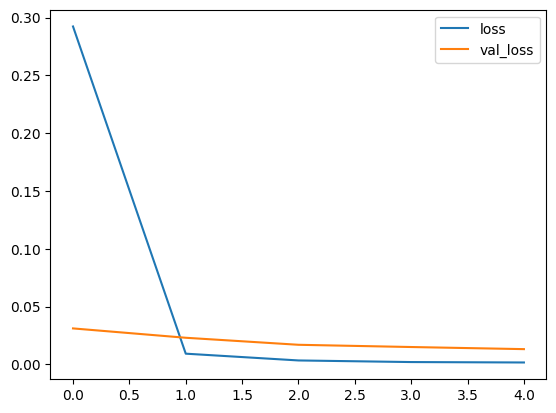

In [64]:
# loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

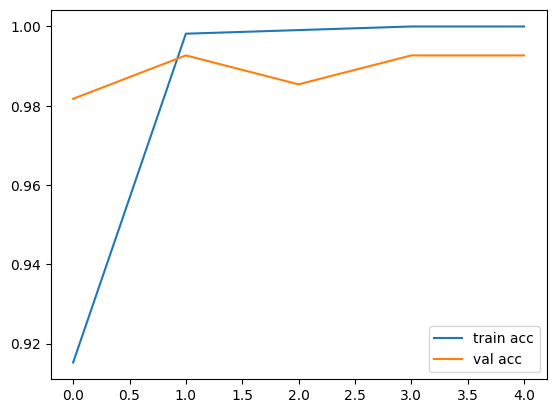

In [65]:
# accuracies
import matplotlib.pyplot as plt
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [66]:
import tensorflow as tf
import keras as k
print(tf.__version__)
print(k.__version__)

2.18.0
3.7.0


In [67]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


Found 1097 images belonging to 2 classes.
Found 274 images belonging to 2 classes.
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 985ms/step - accuracy: 0.7290 - loss: 1.6784 - val_accuracy: 0.9781 - val_loss: 0.0540
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 897ms/step - accuracy: 0.9969 - loss: 0.0161 - val_accuracy: 0.9964 - val_loss: 0.0147
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 947ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9964 - val_loss: 0.0152
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 34s 956ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9964 - val_loss: 0.0133
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 940ms/step - accuracy: 1.0000 - loss: 5.1764e-04 - val_accuracy: 0.9927 - val_loss: 0.0142
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 888ms/step - accuracy: 1.0000 - loss: 1.7232e-04 - val_accuracy: 0.9927 - val_loss: 0.0148
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 932ms/step - accuracy: 1.0000 - loss: 5.9241e-05 - val_accuracy: 0.9927 - val_loss: 0.0132
Ep

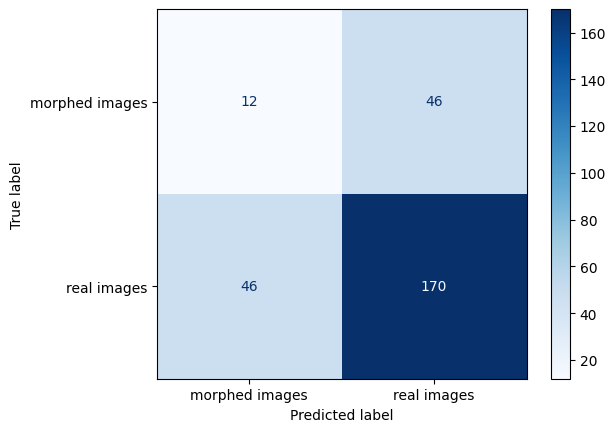

In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# Paths to the dataset (update according to your environment)
dataset_path ='D:/face morphing/Dataset/datasets/train/'  # Provide the path to the dataset

# Preprocessing using ImageDataGenerator for augmentation
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Loading the dataset into train and validation generators
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Create a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(train_gen.class_indices), activation='softmax')  # Number of classes
])

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_gen, epochs=10, validation_data=val_gen)

# Evaluate the model on validation data
y_true = val_gen.classes  # True labels
y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)  # Predicted class labels

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display the confusion matrix using matplotlib
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(train_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.show()
